In [1]:
import numpy as np
import sys
sys.path.append('../../../src')
from data_loader import DataLoader
from noise_optimizers import EnKF_NoiseOptimizer

%matplotlib inline
np.random.seed(777)

## Load data

In [2]:
kitti_root_dir = '../../../data'
noise_vector_dir = '../../../exports/_noise_optimizations/noise_vectors'
kitti_date = '2011_09_30'
kitti_drive = '0016'
data = DataLoader(sequence_nr=kitti_drive, 
                kitti_root_dir=kitti_root_dir, 
                noise_vector_dir=noise_vector_dir,
                vo_dropout_ratio=0.0, 
                gps_dropout_ratio=0.0,
                upsampling_factor=10,
                downsampling_ratio=0.8,
                visualize_data=False)

Data sampling is set to normal mode.


In [3]:
error_df_export_path = '../../../exports/_noise_optimizations/errors/enkf'
noise_vector_export_path = '../../../exports/_noise_optimizations/noise_vectors/enkf'

In [4]:
enkf_optimizer = EnKF_NoiseOptimizer(data=data, 
                                   error_df_export_path=error_df_export_path, 
                                   noise_vector_export_path=noise_vector_export_path)

In [5]:
enkf_optimizer.compare(load_exported=True)

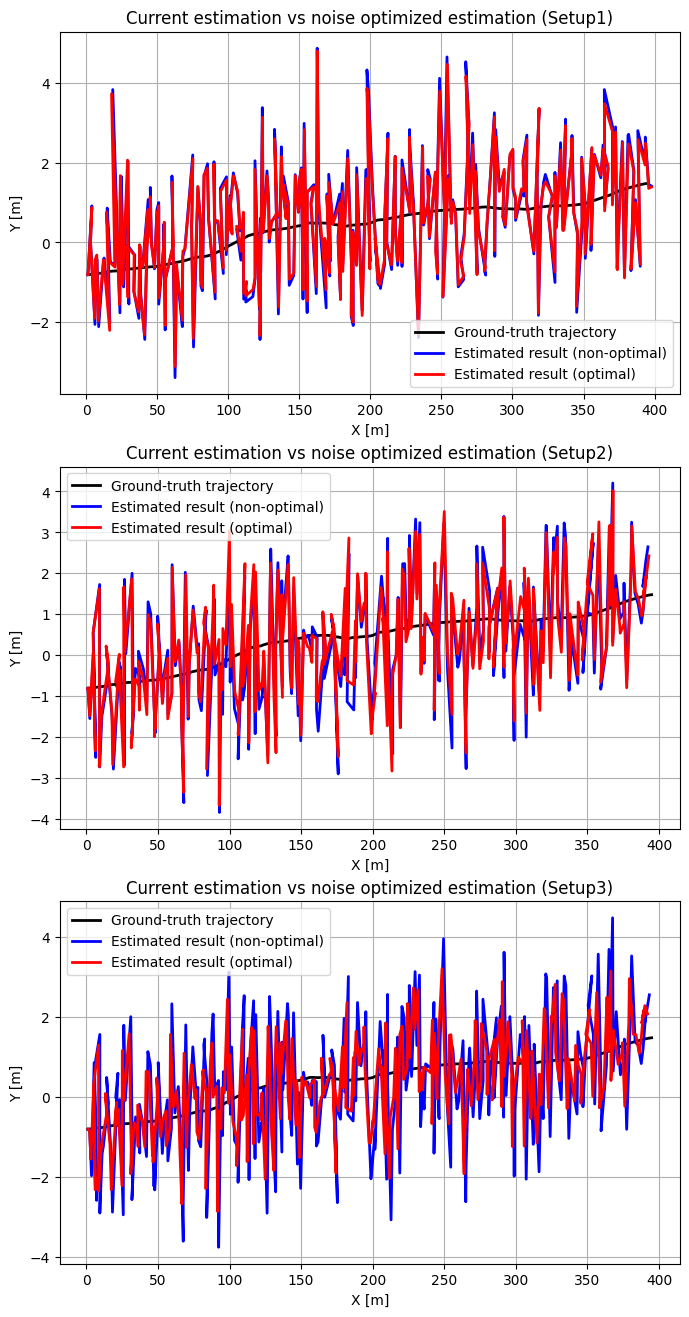

In [6]:
enkf_optimizer.visualize_results()

In [7]:
enkf_optimizer.error_df

Setups        Setup1(IMU+VO)               Setup2(IMU+VO,GPS)                \
Error types              MAE   RMSE    MAX                MAE   RMSE    MAX   
Non-optimized          1.212  1.505  4.712              1.019  1.292  3.606   
Optimized              1.180  1.469  4.754              0.992  1.256  3.473   
∆                     -0.032 -0.036  0.042             -0.027 -0.036 -0.133   

Setups        Setup3(INS)                
Error types           MAE   RMSE    MAX  
Non-optimized       0.942  1.214  3.674  
Optimized           1.109  1.361  4.276  
∆                   0.167  0.147  0.602

## Conclusion